Objective: Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

%matplotlib inline

Upload Dataset

In [2]:
df = pd.read_csv('/content/retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Initial Inspection

Requirement Covered

✔ Shape

✔ Data Types

✔ Null Values

In [3]:
df.shape

(1000, 9)

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [5]:
df.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [7]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [8]:
df.dropna(inplace=True)

Data Cleaning

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


Descriptive Statistics

Requirement Covered

Mean

Median

Mode

In [12]:
df.mean(numeric_only=True)

,0
Transaction ID,500.500
Age,41.392
Quantity,2.514
Price per Unit,179.890
Total Amount,456.000


In [13]:
df.median(numeric_only=True)

,0
Transaction ID,500.5
Age,42.0
Quantity,3.0
Price per Unit,50.0
Total Amount,135.0


In [14]:
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


Time Series Analysis

In [15]:
df.std(numeric_only=True)

,0
Transaction ID,288.819436
Age,13.681430
Quantity,1.132734
Price per Unit,189.681356
Total Amount,559.997632


In [16]:
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
df['Month'] = df['Date'].dt.to_period('M')

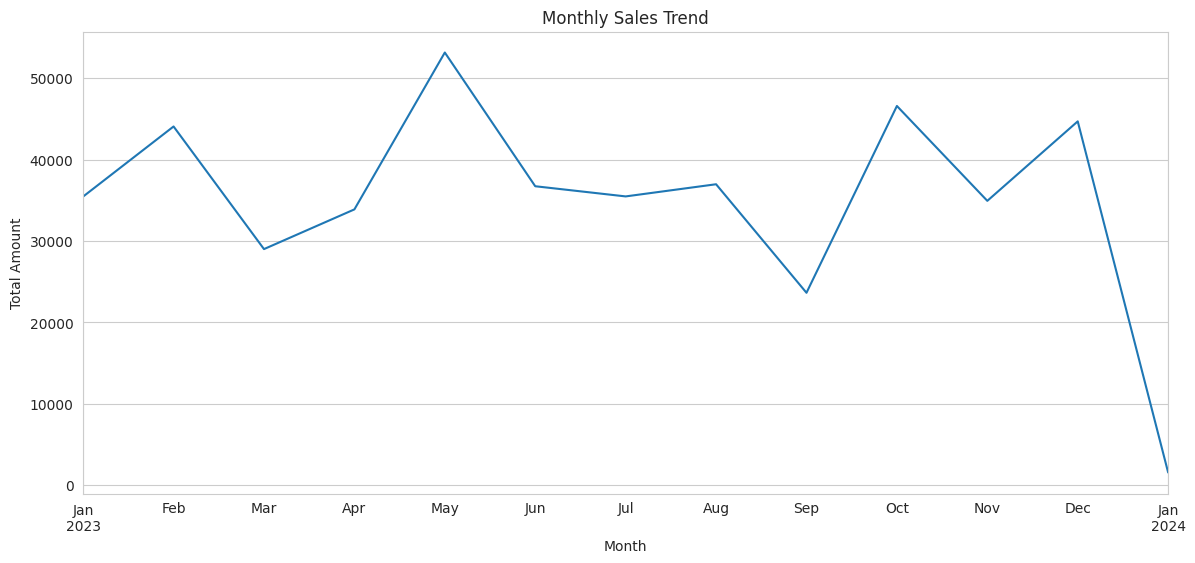

In [18]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Amount")

plt.show()

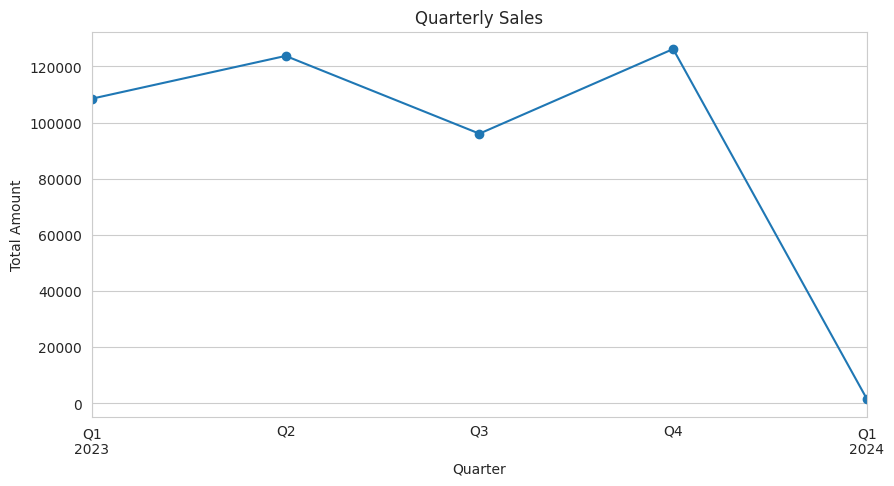

In [19]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarter_sales = df.groupby('Quarter')['Total Amount'].sum()

plt.figure(figsize=(10,5))

quarter_sales.plot(marker='o')

plt.title("Quarterly Sales")
plt.ylabel("Total Amount")

plt.show()

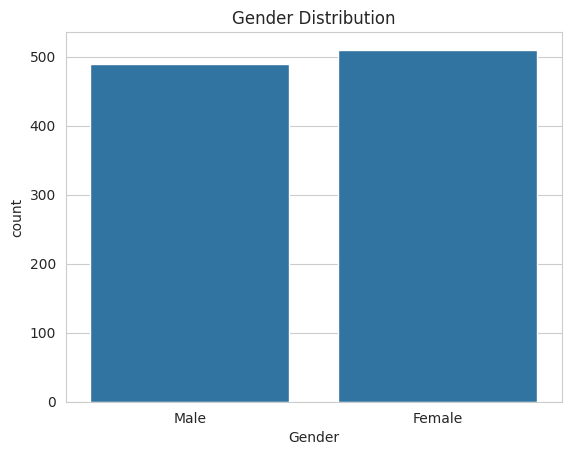

In [20]:
sns.countplot(data=df,x='Gender')

plt.title("Gender Distribution")

plt.show()

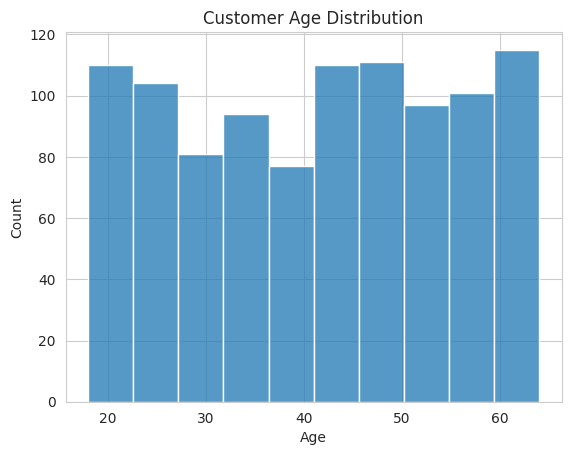

In [21]:
sns.histplot(df['Age'],bins=10)

plt.title("Customer Age Distribution")

plt.show()

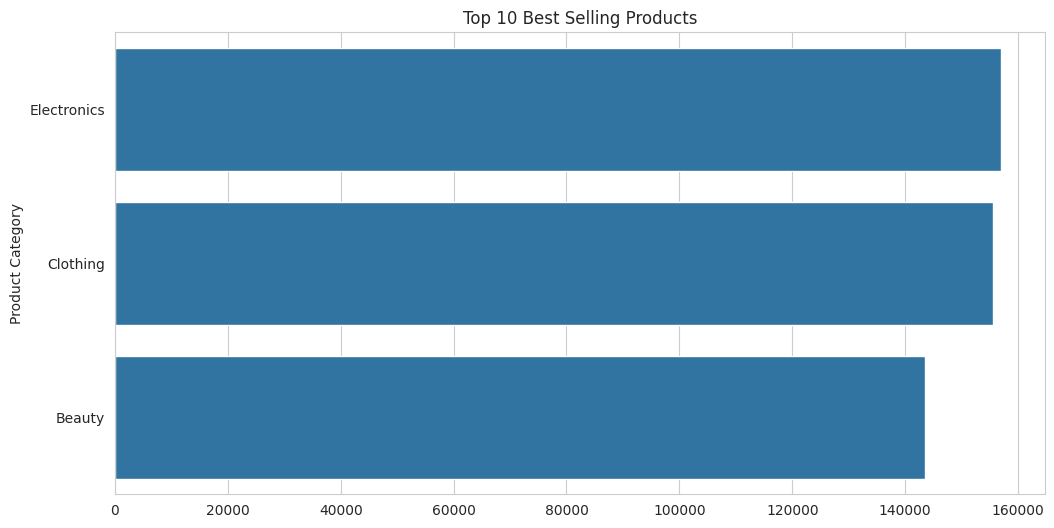

In [22]:
top_products = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values,
            y=top_products.index)

plt.title("Top 10 Best Selling Products")

plt.show()

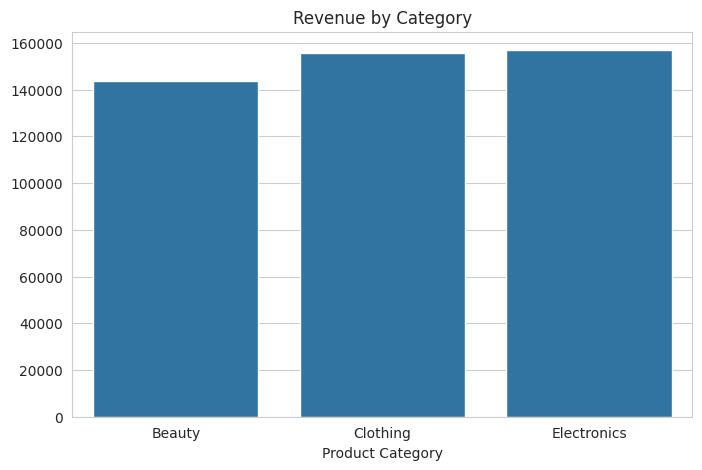

In [23]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.index,
            y=category_sales.values)

plt.title("Revenue by Category")

plt.show()

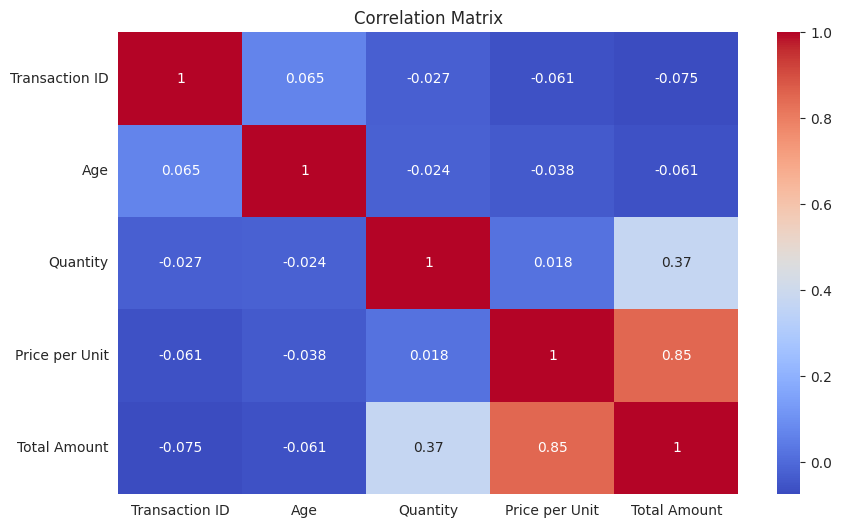

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

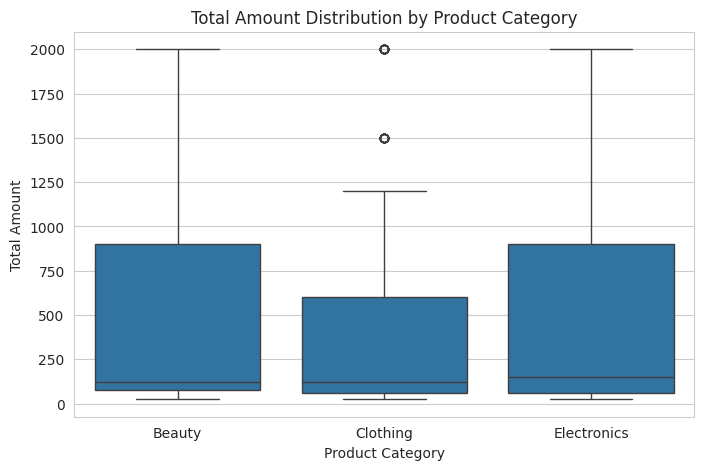

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x='Product Category',
            y='Total Amount')

plt.title("Total Amount Distribution by Product Category")

plt.show()

# Key Insights

1. Sales increase during certain months, indicating seasonal demand.

2. A few products generate a large portion of total revenue.

3. Most customers belong to a specific age group.

4. Product categories differ significantly in revenue contribution.

5. Certain regions outperform others in total sales.

# Conclusion

### Business Recommendations

1. Increase inventory during peak sales months to avoid stock shortages.

2. Focus marketing campaigns on the highest revenue-generating products and categories.

3. Offer personalized promotions to the largest customer age group.

4. Expand operations or advertising in high-performing regions.

5. Improve sales of low-performing categories using discounts and bundled offers.